# 1. Data
## 1.1 Load Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Concrete_Data_Yeh.csv')
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 1.2 Summarize the Data


In [2]:
df


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


In [3]:
df.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


##  Observations:
- From the data set we can find that there are no missing values for each column
- Most  of the features are components of concrete mixture and how much quantities are used. 
- The `age` column defines how much day the concrete has been kept to cure.
- Concrete compressive strength is the target variable and highest strength it achieved was 82.6 MPa, Minimum value it achieved was 2.3 MPa  and also keeping an average strength of 35.8 MPa all along.

## 1.3  Checking the Datatype and Missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
cement              1030 non-null float64
slag                1030 non-null float64
flyash              1030 non-null float64
water               1030 non-null float64
superplasticizer    1030 non-null float64
coarseaggregate     1030 non-null float64
fineaggregate       1030 non-null float64
age                 1030 non-null int64
csMPa               1030 non-null float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [5]:
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

- There are no missing or null values
- Most of the columns are Float and the age is integer.

In [6]:
df.duplicated
df.duplicated().sum()

25

- From here we checked for the duplicate values and  found out there are 25 duplicate values in the data set 

In [7]:
df = df.drop_duplicates()


In [8]:
df.duplicated().sum()

0

- We have dropped the duplicates adn fixed the data set now the duplicates are 0

## 1.3 Plotting Heatmap and Pairplot

### 1.3.1 Heatmap

Text(0.5, 1, 'Correlation Heatmap of Concrete Data Features')

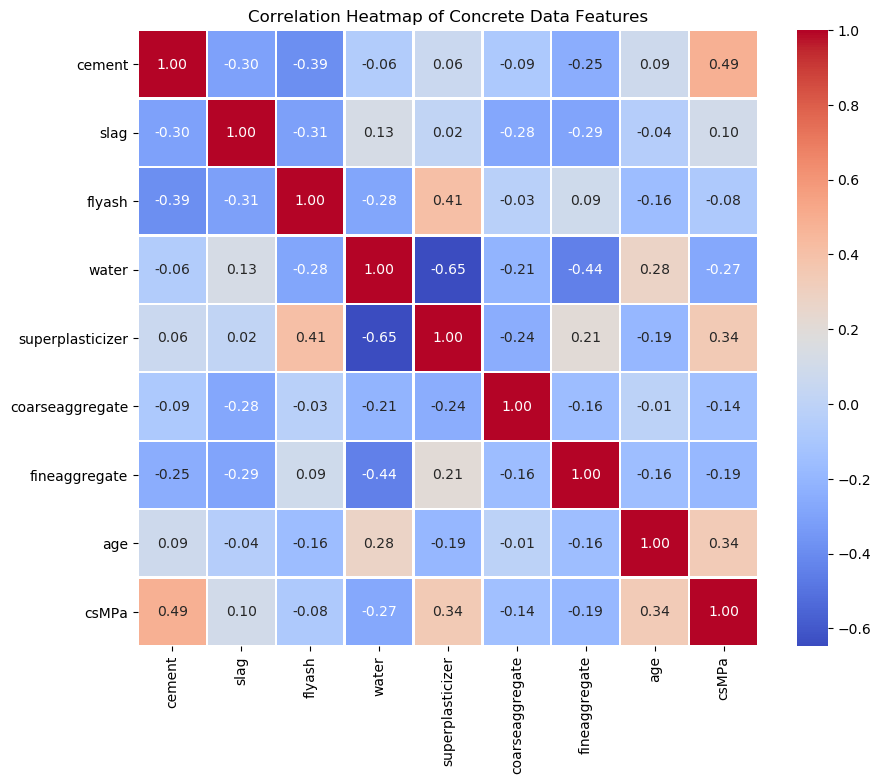

In [9]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Concrete Data Features")

### 1.3.2 Pairplot

Instead of using `sns.pairplot()`, we decided to implement a subplots approach as we want to compare each one of the features to the target variable (concrete strength) instead of comparing every feature to others. This makes it clear and easier to visualize.

Each one of the plots includes a regression line that represent the relationship between each particular feature and the target variable.

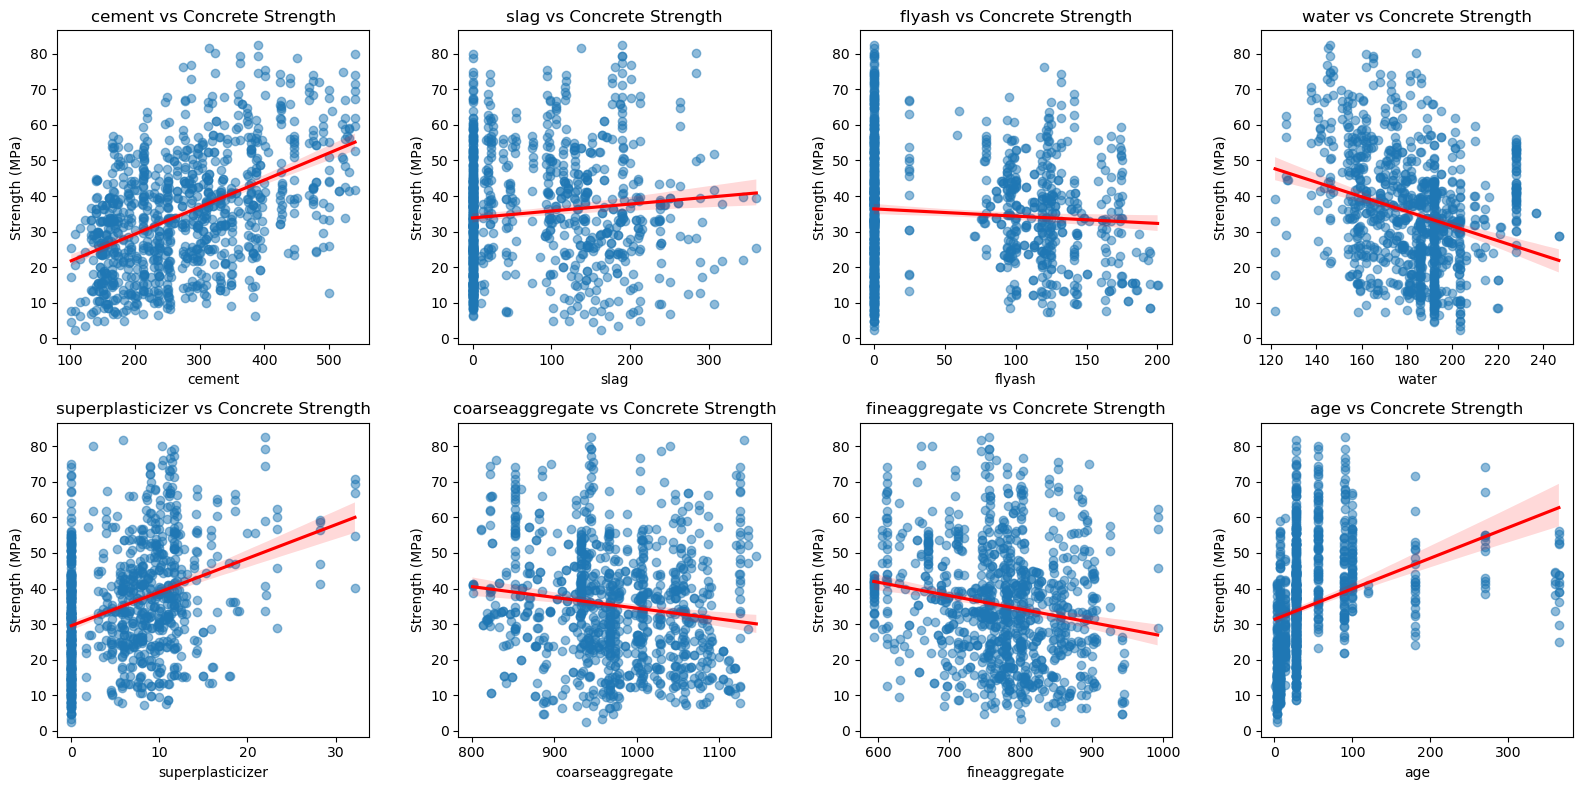

In [10]:
# Specifying the features we want to plot in the pair plot 
features = ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 
            'coarseaggregate', 'fineaggregate', 'age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.regplot(data=df, x=feature, y='csMPa', ax=axes[idx], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[idx].set_title(f'{feature} vs Concrete Strength')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Strength (MPa)')

plt.tight_layout()
plt.show()

### 1.3.3 Histograms

AttributeError: module 'seaborn' has no attribute 'histplot'

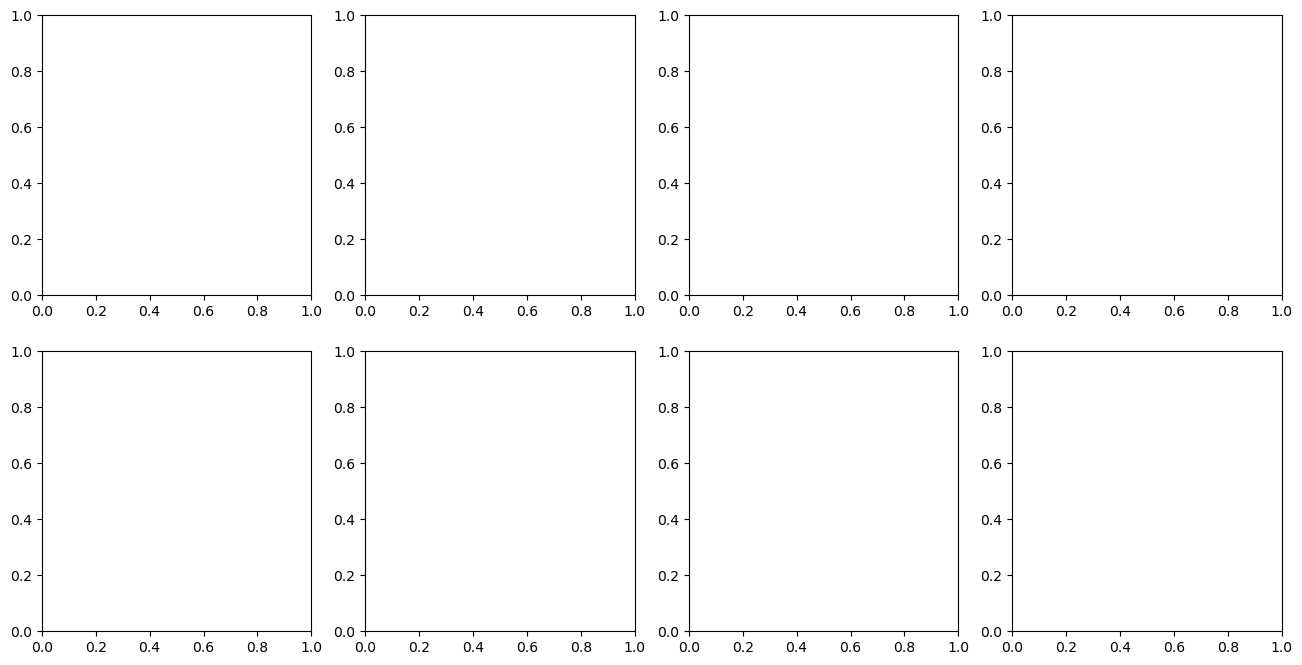

In [11]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.histplot(data=df, x=feature, ax=axes[idx], kde=True)
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 1.3.4 Findings
**Heatmap Findings:**
- The most correlated component to the concrete compressive strength is the `cement`, also showing a considerable correlation with the `age` and the `superplasticizer`, meaning these components contribute to the compressive strength.
- Components like `flyash` and `superplasticizer` show a considerable correlation, meaning they are included in similar proportions.
- `superplasticizer` and `water` show an inverse correlation, meaning that in most of the cases the more water is used for the mixture, the less superplasticizer is used and viceversa.

**Pairplot Findings**

Following up with the heatmap findings, the pairplot supports the positive relationship between cement and the compressive strength, showing significant correlation between age and superplasticizer as well. 

**Histogram Findings**
- Columns like `slag`, `flyash` and `age` are skewed to the right, meaning that most of the ratios are low for this components.
- Some features also show a normal distribution, those are `water`, `coarseaggregate`, `fineaggregate`. Possible assumptions can me made about these features behaviour based on this shape.

## 1.4 Separating and Scaling Data
- Saving the csMPA column (the label y)
- and using the other columns(the features X) as separated features.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = df.drop(columns=['csMPa']).values
labels = df[['csMPa']].values

# Scaling the features
x_scaler = StandardScaler()
x_scaled = x_scaler.fit_transform(features)

# Splitting the dataset using 90% for training and 10% for testing
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, labels, test_size=0.1, random_state=42
)

# 2. Modeling

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


## 2.1 Tensorflow variables
- Saving the csMPA column (the label y) as a 2D tensorflow variable
- and using the other columns(the features X) as seperate 2D tensorflow variable.

In [ ]:
y_label_train = tf.Variable(y_train, dtype=tf.float32)
y_label_test = tf.Variable(y_test, dtype=tf.float32)

X_input_train = tf.Variable(X_train, dtype=tf.float32)
X_input_test = tf.Variable(X_test, dtype=tf.float32)

### 2.1.1 Printing the input (X) features

In [ ]:
X_input_train[:5]

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[ 0.5788408 , -0.83647066, -0.865375  ,  0.6997457 , -1.0196404 ,
        -0.08223792,  0.10350803, -0.5000821 ],
       [-0.46917486, -0.83647066,  0.9764346 ,  0.61535245,  0.01128375,
         0.69283533, -0.18789755, -0.67275846],
       [-0.7539513 , -0.83647066, -0.865375  , -0.09730185, -1.0196404 ,
         1.9424958 ,  0.9005147 , -0.28031212],
       [-0.5545119 ,  0.872615  , -0.865375  ,  0.16994351, -1.0196404 ,
         1.0397483 , -0.35352552, -0.60996705],
       [-0.25727051, -0.83647066,  0.6912813 , -1.6867085 ,  1.0760088 ,
         0.40782502,  1.5829517 , -0.67275846]], dtype=float32)>

### 2.1.1 Printing the label

In [ ]:
y_label_train[:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[27.04],
       [13.36],
       [12.25],
       [13.09],
       [21.02]], dtype=float32)>

## 2.1 Creating initial weigths and bias vectors 
- Using tf.zeros to create tensorflow variables of the appropriate shape for the weights (w) and bias (b)

In [ ]:
Number_of_features = 8
Number_of_units = 1 

weights = tf.Variable(tf.zeros([Number_of_features, Number_of_units]))  
bias = tf.Variable(tf.zeros([Number_of_units]))

## 2.2 Regression Function Definition

-  Writing a regression function to implement the equation z=xw+b and return the value z

In [ ]:
def regression(x,weight,bias):
    # x is the input (features)
    # w is the weight
    # b is th bias
    z = tf.add(tf.matmul(x,weight),bias)
    return z

## 2.3 Loss Function
- Writing a loss function as a lambda funtion  that calculates |y-y hat| where y is the label and the y hat is the prediction

In [ ]:
loss = lambda y, y_hat: tf.reduce_mean(tf.abs(y - y_hat))

## 2.4 Train Function

- Train function that uses tf.optimizer.SGD to minimize the loss with respect to w and b.

In [ ]:
def train(x, y, weight, bias, learning_rate, epochs=5000):

    optimizer = tf.optimizers.SGD(learning_rate)
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            yhat = regression(x, weight, bias)
            current_loss = loss(y, yhat)

        dw, db = tape.gradient(current_loss, [weight, bias])

        optimizer.apply_gradients([(dw, weight), (db, bias)])

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss = {current_loss.numpy()}")

    return weight, bias


In [ ]:
w_trained, b_trained = train(X_input_train, y_label_train, weights, bias, learning_rate=0.1, epochs=1000)

Epoch 0, Loss = 34.948509216308594
Epoch 100, Loss = 25.281543731689453
Epoch 200, Loss = 18.124839782714844
Epoch 300, Loss = 13.015395164489746
Epoch 400, Loss = 10.360503196716309
Epoch 500, Loss = 9.193690299987793
Epoch 600, Loss = 8.65131950378418
Epoch 700, Loss = 8.42431926727295
Epoch 800, Loss = 8.320549011230469
Epoch 900, Loss = 8.252310752868652


## 2.5 Finding RMSE
- Printing out the Trained weights and bias

In [ ]:
print("Trained weights:\n", w_trained.numpy())
print("\nTrained bias:\n", b_trained.numpy())

Trained weights:
 [[ 7.6377053]
 [ 3.4797568]
 [ 0.6547342]
 [-5.079348 ]
 [ 3.3520005]
 [-1.8940275]
 [-2.390812 ]
 [ 8.070769 ]]

Trained bias:
 [35.314262]


- Calculate predictions

In [ ]:
predictions = regression(X_input_train, w_trained, b_trained)
# Finding RMSE 
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

rmse_value = rmse(y_label_train, predictions)
print("RMSE on Training Data:", rmse_value.numpy())

RMSE on Training Data: 10.485163


# 3. Conclusion
## 3.1 Predictions on Test Data

In [ ]:
predictions_test = regression(X_input_test, w_trained, b_trained)

## 3.2 Percentage Function Coding

In [ ]:
deviations_perc = lambda arr : (sum([1 for x in arr if abs(x) > rmse_value.numpy()])/len(arr))*100
percentage = deviations_perc(predictions_test.numpy()-y_label_test.numpy())
print(f"Percentage of test predictions deviating from true values by more than RMSE: {percentage:.2f}%")

Percentage of test predictions deviating from true values by more than RMSE: 31.68%


## 3.3  Functionality Conclusions
- The model's performance is not perfect, but it is a good starting model with an RMSE score of 10.48 MPa. This means that the typical prediction error is around +- 10.48 MPa and should be taken into account when trying to obtain prediction with new data. The model needs refinement, implementing more layers and a more robust ANN so it can make more accurate predictions, but provides a starting point for further development.

- Structural engineers should consider that the model presents around 30% of test predictions have errors exceeding the RMSE threshold, meaning 70% of predictions fall within the ±10.48 MPa error range, and would be accurate enough for non-risky decisions. They shouldn't base their decisions on the model as the risk of an inaccurate prediction is still very significant, but can help to automate minor concrete strength assessment tasks.
